# CQF Exam 1 - By Stephane Mertens de Wilmars (March 2026)

##  Task 0 - Data Loading and exploration

 missing data?
^GSPC    0
^NDX     0
dtype: int64

assets: 2: ['^GSPC', '^NDX']
Days: 2587 between 2015-10-16 00:00:00 and 2026-01-30 00:00:00
Years: 10.30

        count      mean       std       min       25%       50%       75%  \
^GSPC  2587.0  0.000541  0.011352 -0.119841 -0.003641  0.000721  0.005800   
^NDX   2587.0  0.000779  0.014124 -0.121932 -0.005020  0.001321  0.007844   

            max  
^GSPC  0.095154  
^NDX   0.120223  

correl: 0.97


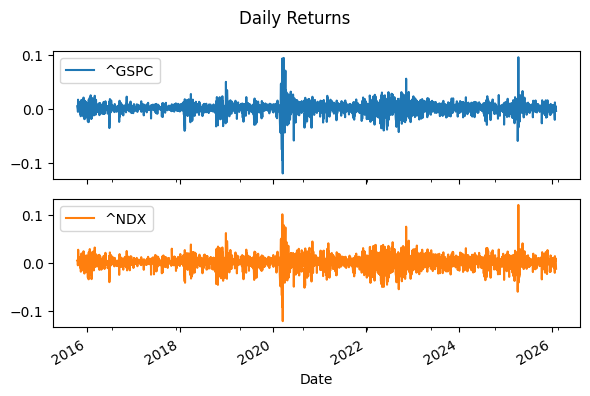

In [1]:
#imports
import pandas as pd
import matplotlib.pyplot as plt

# load the excel
df = pd.read_excel('Indices_Download_2026.xlsx')

#make it workable
df = df.set_index(df.columns[0])

#count missing values
print(f' missing data?')
print(f'{df.isna().sum()}')
print()

returns = df.pct_change().dropna()

#assets and observations
print(f'assets: {returns.shape[1]}: {returns.columns.tolist()}') #GSPC IS SP500, NDX is nasdax, 
print(f'Days: {returns.shape[0]} between {returns.index[0]} and {returns.index[-1]}')
print(f'Years: {(returns.index[-1] - returns.index[0]).days/365:.2f}')
print()

#summary stats of returns
print(returns.describe().T)
print()

#avg correlation between assets
print(f'correl: {returns.corr().values.mean():.2f}')

#plot returns for each
axes = returns.plot(subplots=True, figsize=(6, 4), title='Daily Returns')
plt.tight_layout()
plt.savefig('Daily_Returns.png', dpi=300)


The provided data file has roughly 10 years of daily prices for the SP500 & NASDAQ 100 between Q4 2015 and Q1 2026. Looking at the returns, we see that they are highly correlated (97% over the period) and have comparable return and volatility profile, with NASDAQ100 slightly higher values for both. 


| Asset | Mean  | Vol |
| :--- | :--- | :--- |
|SP500| 0.054% | 1.135% |
| NASDAQ100 | 0.078% | 1.412% |

Below the return series are plotted. The three biggest volatility spikes in the period seem to be in 2020 (covid), 2022-2023 (Ukraine Invasion / SVB collapse) and 2025 (Liberation day).

![Daily Returns Chart](Daily_Returns.png)


## Task 1 Min Variance Portfolio

### Task 1 Data

| Asset | $\mu$ | vol| Weight |
| :--- | :--- | :--- | :--- |
| **A** | 0.02 | 0.05 | $w_A$ |
| **B** | 0.07 | 0.12 | $w_B$ |
| **C** | 0.15 | 0.17 | $w_C$ |
| **D** | 0.20 | 0.25 | $w_D$ |

**Correlation Matrix ($R$):**

$$
R = \begin{pmatrix}
1 & 0.3 & 0.3 & 0.3 \\
0.3 & 1 & 0.6 & 0.6 \\
0.3 & 0.6 & 1 & 0.6 \\
0.3 & 0.6 & 0.6 & 1
\end{pmatrix}
$$

### Answer 1a: Lagrangian Formulation
To find the lagrangian, we need first define the covariance matrix by multiplying the correlations with the volatilities of the assets. The covariance matrix $\Sigma$ is thus defined as:

$$ \Sigma = \begin{pmatrix}
1*0.05^2 & 0.3*0.05*0.12 & 0.3*0.05*0.17 & 0.3*0.05*0.25 \\
0.3*0.05*0.12 & 1*0.12^2 & 0.6*0.12*0.17 & 0.6*0.12*0.25 \\
0.3*0.05*0.17 & 0.6*0.12*0.17 & 1*0.17^2 & 0.6*0.17*0.25 \\
0.3*0.05*0.25 & 0.6*0.12*0.25 & 0.6*0.17*0.25 & 1*0.25^2

\end{pmatrix} $$

Simplify:

$$ \Sigma = \begin{pmatrix}
0.0025 & 0.0018 & 0.00255 & 0.00375 \\
0.0018 & 0.0144 & 0.01224 & 0.018 \\
0.00255 & 0.01224 & 0.0289 & 0.0255 \\
0.00375 & 0.018 & 0.0255 & 0.0625
\end{pmatrix} $$

Its transpose is the same as the original as its symmetric.



Next, define the optimization problem

1. Choose weights of assets that minimize the variance of the portfolio

Define W as vector of weights [$w_A, w_B, w_C, w_D$].

The minimization problem is thus

$$ min 1/2 W^T * \Sigma * W $$



2. constraint 1: The return must equal $m$

$$ W^T \mu = m $$

3. constraint 2: The weights must sum to 1, e.g. all money is invested, ignore presence of a risk free asset

$$ W^T \mathbf{1} = 1 $$

A simple 2 constraint Lagrangian for a function is defined as

$$ L(x, \lambda_1, \lambda_2) = f(x) + \lambda_1 g(x) + \lambda_2 h(x) $$




For the problem at hand, first rewrite the constraints as lambda functions

$$ g(W) = W^T \mu - m $$
$$ h(W) = W^T \mathbf{1} - 1 $$

**Then the lagrangian is:**

$$ L(W, \lambda_1, \lambda_2) = 1/2 W^T \Sigma W + \lambda_1 (W^T \mu - m) + \lambda_2 (W^T \mathbf{1} - 1) $$


To find the first conditions, partial derivatives set to zero need to be found to W, $\lambda_1$ and $\lambda_2$.

$$\frac{\partial L}{\partial W} = \Sigma W + \lambda_1 \mu + \lambda_2 \mathbf{1} = 0 $$
$$\frac{\partial L}{\partial \lambda_1} = W^T \mu - m = 0 $$
$$\frac{\partial L}{\partial \lambda_2} = W^T \mathbf{1} - 1 = 0 $$

Rewrite. **These are the first order conditions**:

$$ W = - \lambda_1 \Sigma^{-1} \mu - \lambda_2 \Sigma^{-1} \mathbf{1} $$
$$ m = W \mu $$
$$ 1 = W \mathbf{1} $$



### Answer 1b

Rewrite the second and third first order conditions with the first one incorporated:

$$ m = (- \lambda_1 \Sigma^{-1} \mu - \lambda_2 \Sigma^{-1} \mathbf{1})^T \mu $$
$$ 1 = (- \lambda_1 \Sigma^{-1} \mu - \lambda_2 \Sigma^{-1} \mathbf{1})^T \mathbf{1} $$

Rewrite in terms of $\lambda_1$:

$$ \lambda_1 = \frac{-m - \lambda_2 \mathbf{1}^T \Sigma^{-1} \mu}{\mu^T \Sigma^{-1} \mu} $$
$$ \lambda_1 = \frac{-1 - \lambda_2 \mathbf{1}^T \Sigma^{-1} \mathbf{1}}{\mu^T \Sigma^{-1} \mathbf{1}} $$

Incorporate the first $\lambda_1$ equation into the second:

$$ \frac{-m - \lambda_2 \mathbf{1}^T \Sigma^{-1} \mu}{\mu^T \Sigma^{-1} \mu} = \frac{-1 - \lambda_2 \mathbf{1}^T \Sigma^{-1} \mathbf{1}}{\mu^T \Sigma^{-1} \mathbf{1}} $$

Rearrange:

$$ \lambda_2 = \frac{m \mu^T \Sigma^{-1} \mathbf{1} - \mu^T \Sigma^{-1} \mu}{\mu^T \Sigma^{-1} \mu * \mathbf{1}^T \Sigma^{-1} \mathbf{1} - (\mathbf{1}^T \Sigma^{-1} \mu)^2} $$

Fill into the first equation again, to find $\lambda_1$ without reference to $\lambda_2$:

$$ \lambda_1 = \frac{-m - \frac{m \mu^T \Sigma^{-1} \mathbf{1} - \mu^T \Sigma^{-1} \mu}{\mu^T \Sigma^{-1} \mu * \mathbf{1}^T \Sigma^{-1} \mathbf{1} - (\mathbf{1}^T \Sigma^{-1} \mu)^2} * \mathbf{1}^T \Sigma^{-1} \mu}{\mu^T \Sigma^{-1} \mu} $$

These results can be incorporated into the first equation to define W without reference to $\lambda_1$ and $\lambda_2$:

$$ W = - \frac{-m - \frac{m \mu^T \Sigma^{-1} \mathbf{1} - \mu^T \Sigma^{-1} \mu}{\mu^T \Sigma^{-1} \mu * \mathbf{1}^T \Sigma^{-1} \mathbf{1} - (\mathbf{1}^T \Sigma^{-1} \mu)^2} * \mathbf{1}^T \Sigma^{-1} \mu}{\mu^T \Sigma^{-1} \mu} * \Sigma^{-1} \mu - \frac{m \mu^T \Sigma^{-1} \mathbf{1} - \mu^T \Sigma^{-1} \mu}{\mu^T \Sigma^{-1} \mu * \mathbf{1}^T \Sigma^{-1} \mathbf{1} - (\mathbf{1}^T \Sigma^{-1} \mu)^2} * \Sigma^{-1} \mathbf{1} $$

**The above can be simplified by defining A,B,C,D, or just computed directly**

$$ A = \mathbf{1}^T \Sigma^{-1} \mathbf{1} $$
$$ B = \mathbf{1}^T \Sigma^{-1} \mu $$
$$ C = \mu^T \Sigma^{-1} \mu $$
$$ D = AC - B^2 $$



In [2]:
import numpy as np

def min_var_portfolio(mu, Sigma, m):
    Sigma_inv = np.linalg.inv(Sigma)
    ones = np.ones(len(mu))

    W = (
        -((-m - (m * (mu @ Sigma_inv @ ones) - (mu @ Sigma_inv @ mu))
           / ((mu @ Sigma_inv @ mu) * (ones @ Sigma_inv @ ones) - (ones @ Sigma_inv @ mu)**2)
           * (ones @ Sigma_inv @ mu))
          / (mu @ Sigma_inv @ mu))
        * (Sigma_inv @ mu)
        - ((m * (mu @ Sigma_inv @ ones) - (mu @ Sigma_inv @ mu))
           / ((mu @ Sigma_inv @ mu) * (ones @ Sigma_inv @ ones) - (ones @ Sigma_inv @ mu)**2))
        * (Sigma_inv @ ones)
    )
    p_vol = np.sqrt(W @ Sigma @ W)
    return W, p_vol

# Inputs
mu = np.array([0.02, 0.07, 0.15, 0.20])
Sigma = np.array([
    [0.0025, 0.0018, 0.00255, 0.00375],
    [0.0018, 0.0144, 0.01224, 0.018],
    [0.00255, 0.01224, 0.0289, 0.0255],
    [0.00375, 0.018, 0.0255, 0.0625]
])
m = 0.045

W, p_vol = min_var_portfolio(mu, Sigma, m)

print(f"W = {W}")
print(f"P Vol = {p_vol:.6f}")
print(f"Constraints? Sum of weights = {W.sum()}, return = {W @ mu}")


# what if target return is higher?

W, p_vol = min_var_portfolio(mu, Sigma, 0.3)

print(f"W = {W}")
print(f"P Vol = {p_vol:.6f}")

#sharpe ratios

sharpe_ratios = mu / np.sqrt(np.diag(Sigma))
print(f"Sharpe Ratios: {sharpe_ratios}")

W = [0.78511066 0.05386419 0.13355472 0.02747042]
P Vol = 0.058401
Constraints? Sum of weights = 0.9999999999999994, return = 0.04500000000000002
W = [-0.60363071 -0.45810693  1.36414855  0.69758908]
P Vol = 0.321706
Sharpe Ratios: [0.4        0.58333333 0.88235294 0.8       ]


### Answer 1c

As found in python, weight and return constraints are satisfied. Portfolio variance is approximately 5.84\%.

### Answer 1d

Explanation 1: Asset one has a very low volatility, so a large weight will not add much portfolio volatility. Given that our target return is quite low, investor can reach it by investing in A a lot. Alternatively, say investor seeks a 30\% return, and shorting is allowed, they would short the low return, low vol assets A \& B, and invest in the high return, high vol assets C \& D. The sharpe-ratio's computed in python are indicative of this, as most weighting will fall on the higher sharpe ratio assets C, D.**

**Explanation 2: A has a 30\% correlation with all other assets, whereas the other assets have 60\% correlation with each other. This means adding a lot of A to the portfolio has diversification benefits. Remember portfolio volatility function: The portfolio volatility is not just the weighted sum of volatilities, but also includes covariance term, which for combinations involving A is lower than for combinations of B, C, D.

$$ \sigma_p = \sqrt{\sum_{i=1}^n w_i^2 \sigma_i^2 + \sum_{i=1}^n \sum_{j \neq i} w_i w_j \sigma_i \sigma_j \rho_{ij}} $$

## Task 2 Var and ES - Sensi's

In [3]:
from scipy.stats import norm

mu = np.array([0, 0, 0])
vols = np.array([0.3, 0.2, 0.15])
W = np.array([0.5, 0.2, 0.3])  

Corr = np.array([
    [1, 0.8, 0.5],
    [0.8, 1, 0.3],
    [0.5, 0.3, 1]]
)   

## get the z score for a given confidence level
confidence_level = 0.99
z_score = norm.ppf(confidence_level)
tail_prob = 1 - confidence_level
print(f"Z-score {-z_score:.4f}")

# Calculate portfolio VaR - parametric

port_vol = np.sqrt(W @ (Corr * np.outer(vols, vols)) @ W)
VaR_99 =  (W @ mu) - z_score * port_vol

#Calculate portfolio cvaR - parametric

cVaR_99 =  (W @ mu) - (norm.pdf(z_score) / tail_prob) * port_vol

print(f"Portfolio VaR: {VaR_99:.4f}")
print(f"Portfolio CVaR: {cVaR_99:.4f}")

# VaR sensitivity function
def VaR_sensitivities(confidence, Corr, mu, vols, W):
    Sigma = Corr * np.outer(vols, vols)

    #get the dot matrix of the weights and the covariance
    sigma_p = np.sqrt(np.dot(W, np.dot(Sigma, W)))

    #return function as specified in the task
    return mu - z_score * np.dot(Sigma, W) / sigma_p

sensis = VaR_sensitivities(tail_prob, Corr, mu, vols, W)


print(f"VaR sensis: {sensis}")





Z-score -2.3263
Portfolio VaR: -0.4855
Portfolio CVaR: -0.5562
VaR sensis: [-0.68386475 -0.38679881 -0.2207094 ]


### Answer 2a

The VaR sensitivities for all assets are correctly given by the AI-Computed solution, as shown in the python results above.

### Answer 2b

The sensitivities are negative, e.g. if the weight of an asset increases, the VaR/ES goes down. This is because VaR and ES are chosen here with a negative sign, e.g. they are negative returns. Industry practice sometimes choses to report them with a flipped sign, as losses which can feel more intuitive "e.g. my VaR is 68\%, so worst case, I get a loss of 68\%" but it fundamentally doesn't matter.

For portfolio management it means that less allocation to an asset will naturally mean there is less downside. Note that in this exercise there is no constraint on the weights being non-zero, expected return etc. so if the goal is to minimize VaR/ES, the portfolio manager can just liquididate fully and allocate all money to a risk free asset, which would have zero VaR/ES.  A more realistic question is what does the difference in magnitude between the sensi's mean? If the risk manager informs you you are exceeding your allocated risk budget, the easiest way to lower your VaR/ES would be to reduce the weight with the highest sensitvity, e.g. asset 1. 


### Answer 2c

The sensitivity for asset 1 is a function of the correlation structure (higher correlations, mean lower diversification benefits), volatility (higher means wider distribution, so the left tail is further from the mean) and allocation (higher \% allocated to a asset means more sensitivity to that asset in defining any property).
As such, it has the highest sensitivity. 

To demonstrate this, below code shows that this holds true if correlations are equalised and volatilities/weights are equalised. 



In [4]:
mu = np.array([0, 0, 0])
vols = np.array([0.3, 0.2, 0.15])
W = np.array([0.5, 0.2, 0.3])  

Corr = np.array([
    [1, 0.8, 0.8],
    [0.8, 1, 0.8],
    [0.8, 0.8, 1]]
)   


sensis = VaR_sensitivities(tail_prob, Corr, mu, vols, W)

print(f"VaR sensis (equal correls): {sensis}")

vols = np.array([0.3, 0.3, 0.3])

sensis = VaR_sensitivities(tail_prob, Corr, mu, vols, W)

print(f"VaR sensis (equal correl+ vols): {sensis}")

vols = np.array([0.3, 0.2, 0.15])

W = np.array([1/3, 1/3, 1/3])  

sensis = VaR_sensitivities(tail_prob, Corr, mu, vols, W)
print(f"VaR sensis (equal correl+ weights): {sensis}")

vols = np.array([0.3, 0.3, 0.3])
W = np.array([1/3, 1/3, 1/3])  

sensis = VaR_sensitivities(tail_prob, Corr, mu, vols, W)
print(f"VaR sensis (equal correl+ weights+ vols): {sensis}")


VaR sensis (equal correls): [-0.68448976 -0.41027521 -0.30927634]
VaR sensis (equal correl+ vols): [-0.67109866 -0.62635875 -0.64127205]
VaR sensis (equal correl+ weights): [-0.66681469 -0.42921405 -0.31616214]
VaR sensis (equal correl+ weights+ vols): [-0.6497136 -0.6497136 -0.6497136]


### Answer 2d

This is easiest to be explained by considering VaR and ES definition. Assume 99\% confidence level.

VaR, point value of the left-tail quantile, of the distribution of returns. Whats the worst loss I can expect with 99\% confidence? 

ES, the sum of the left tail of the distribution, divided by the observations making up that tail. e.g. what is the expected loss beyond the 99\% quantile? Put differently, if we breach VaR, how bad could I expect it to be on average?

In the latter case, its unlikely that the losses to materialise are going to be exactly the VaR amount, as there is a range of losses beyond VaR that could also occur. As such, ES is typically higher than VaR and a better risk metric.

This holds true just as much for the sensitivities, as the sensitivities are just the change in VaR/ES for a change in weight. If ES is higher than VaR, then the change in ES for a change in weight will also be higher.

***Note the mathematical edge case that if in the 1\% left tail all values are exactly the same, ES will equal VaR***

## Task 3 Var Backtesting

Text(0.5, 1.0, 'daily returns and 10-day rolling volatility of SP500')

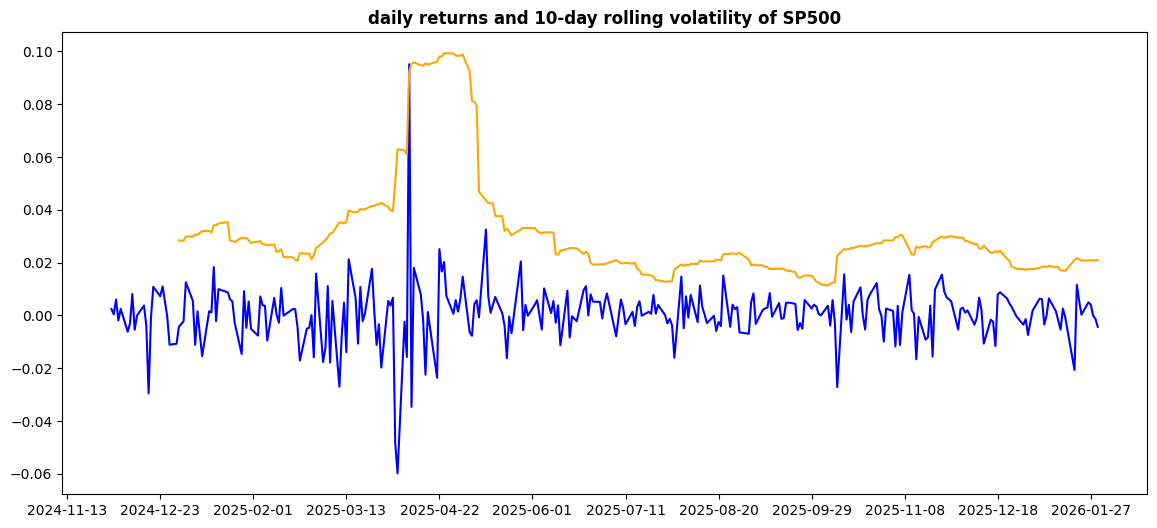

In [5]:
import datetime

start_date = datetime.datetime(2025, 1, 1)
end_date = datetime.datetime(2026, 1, 15)

#clear plots
plt.close('all')

#assumptions
tail_prob = 0.01

#cut returns to size - use searchsorted to handle non-trading days gracefully
start_idx = returns.index.searchsorted(start_date)
end_idx = returns.index.searchsorted(end_date, side='right')

returns_3 = returns.iloc[start_idx - 21 : end_idx + 10] #-21 for rolling window, +10 so fwd returns cover end_date of back test
returns_3 = returns_3['^GSPC']

#convert to forward returns
shift = 10

fwd_r_3 = np.log(1 + returns_3).rolling(shift).sum().shift(-shift) # could have used prices but this is fine as well



#calc the roll_sd

roll_window = 21

roll_sd = returns_3.rolling(window=roll_window).std()

#scale to 10d

sd_10d = np.sqrt(10) * roll_sd


#plot returns and the rolling vol. tic frequency on 4 a month

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(returns_3.index, returns_3, label='Daily Returns', color='blue')
ax.plot(sd_10d.index, sd_10d, label='10-day Rolling Volatility', color='orange')
ax.xaxis.set_major_locator(plt.MaxNLocator(12))
title = "daily returns and 10-day rolling volatility of SP500"
ax.set_title(title, fontweight='bold')


Plotted range: 2025-01-02 to 2026-01-15
Plotted var range: 2025-01-02 to 2026-01-15
backtest contains 270 days



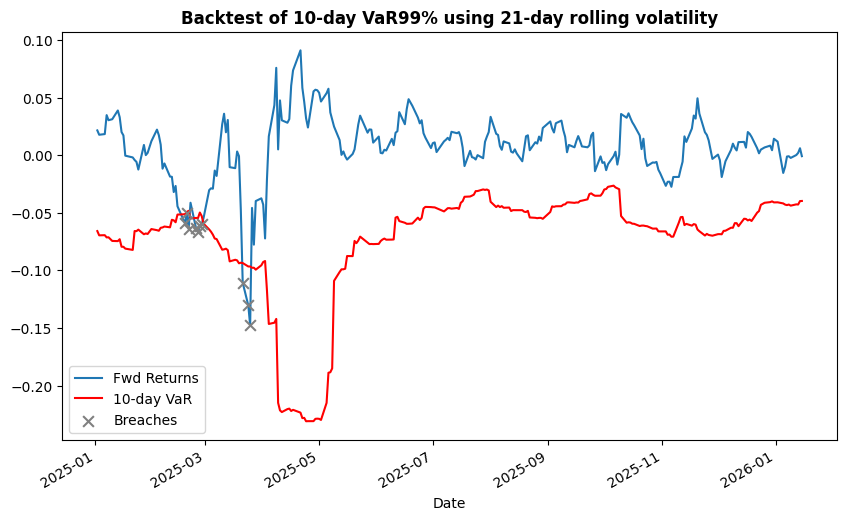

In [6]:
#calculate 10 day var series

VaR_10d = norm.ppf(tail_prob) * sd_10d




#plot returns (ignore na at end), then VaR on same axes
ax = fwd_r_3.iloc[roll_window:].plot(figsize=(10, 6), label='Fwd Returns')
VaR_10d.iloc[roll_window:len(fwd_r_3.dropna())].plot(ax=ax, label='10-day VaR', color='red')

#calc breaches
breaches = fwd_r_3.iloc[roll_window:] < VaR_10d.iloc[roll_window:]


#add breaches
breaches_idx = breaches[breaches].index
ax.scatter(breaches_idx, fwd_r_3.loc[breaches_idx], color='grey', marker='x', s=60, label='Breaches', zorder=4)

#sanity check to ensure plot range is the same
print(f'Plotted range: {fwd_r_3.index[roll_window]:%Y-%m-%d} to {fwd_r_3.index[-(shift+1)]:%Y-%m-%d}')
print(f"Plotted var range: {VaR_10d.index[roll_window]:%Y-%m-%d} to {VaR_10d.index[len(fwd_r_3.dropna())-1]:%Y-%m-%d}")
print(f"backtest contains {len(breaches)} days")
print()

#reporting breaches

breach_count = np.sum(breaches)
observations = len(breaches)
breach_string = f'Var breached {breach_count} times out of {observations} observations ({breach_count/observations:.2%})'

#add title and legend 
ax.set_title(f"Backtest of 10-day VaR99% using 21-day rolling volatility", fontweight='bold')
ax.legend(loc='lower left')

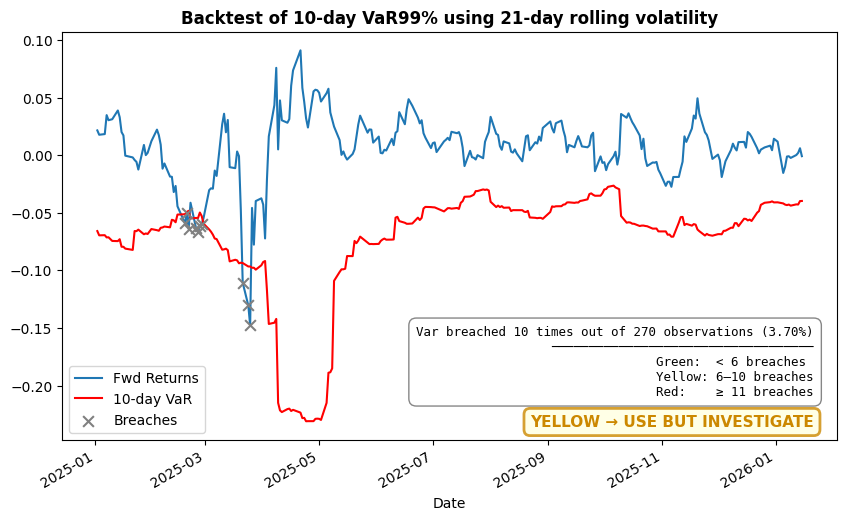

In [7]:
from scipy.stats import binom
#Implementing RYG status

#thresholds
g_prob = 0.95
y_prob = 0.9999

#calculate allowed breaches. 

g_threshold = binom.ppf(g_prob, observations, tail_prob) 
y_threshold = binom.ppf(y_prob, observations, tail_prob)
#Sanity check yellow zone 5-9 with observations=250 OK

RYG_status = 'Green' if breach_count < g_threshold else 'Yellow' if breach_count < y_threshold else 'Red'


# Add comprehensive RYG info box to the plot
info_text = (
    f"{breach_string}\n"
    f"───────────────────────────────────\n"
    f"Green:  < {g_threshold:.0f} breaches \n"
    f"Yellow: {g_threshold:.0f}–{(y_threshold-1):.0f} breaches\n"
    f"Red:    ≥ {y_threshold:.0f} breaches"
)
box_props = dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='grey', alpha=0.95)
ax.text(0.97, 0.28, info_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right',
        bbox=box_props, family='monospace')

# Status line in bold coloured text
status_msg = {'Green': 'GREEN → ACCEPT', 'Yellow': 'YELLOW → USE BUT INVESTIGATE', 'Red': 'RED → DO NOT USE & INVESTIGATE'}
status_clr = {'Green': 'green', 'Yellow': '#CC8800', 'Red': 'red'}
ax.text(0.97, 0.062, status_msg[RYG_status], transform=ax.transAxes, fontsize=11,
        fontweight='bold', color=status_clr[RYG_status],
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                  edgecolor=status_clr[RYG_status], linewidth=2, alpha=0.80))

ax.get_figure().savefig('VaR_Backtest2.png', dpi=300, bbox_inches='tight')
ax.get_figure()





### Answer 3a

Var was breached 10 times out of 270 days in the backtest, this means it was breached in 3.7\% of the observations.

### Answer 3b & 3c

The below plot visualised the breaches, which are clustered around the tarrif announcements surrounding the "Liberation day" in April 2025. The VaR calculated here has poor responsiveness, as it started responding to market volatility after it already passed. 

<img src="VaR_Backtest2.png" width="100%">

Traffic Light ranges are:


* Green: <6 breaches 
* Yellow: 6-10 breaches 
* Red: >= 11 breaches



Plotted range: 2025-01-02 to 2026-01-15
Plotted var range: 2025-01-02 to 2026-01-15
backtest contains 270 days



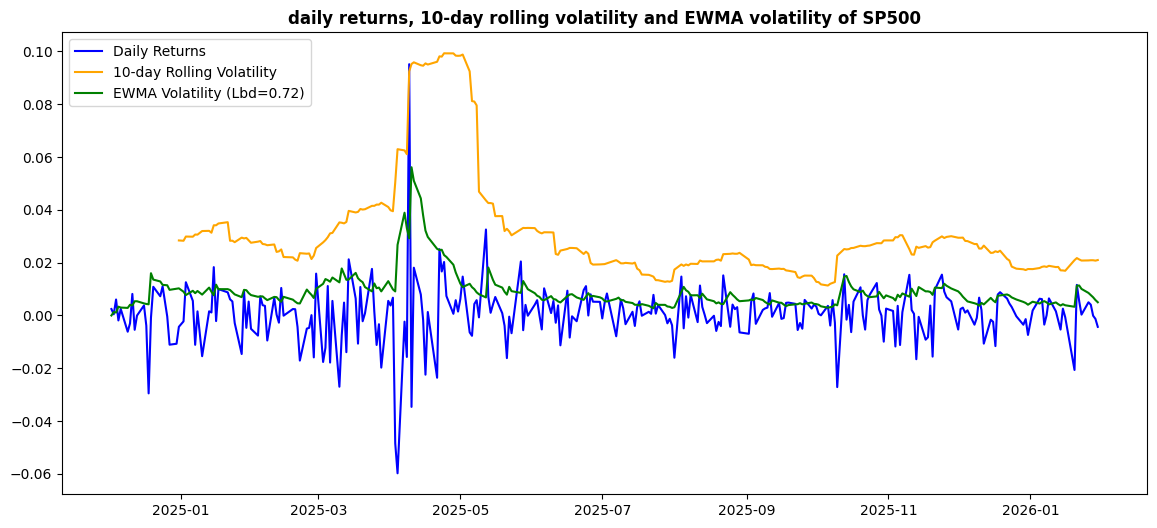

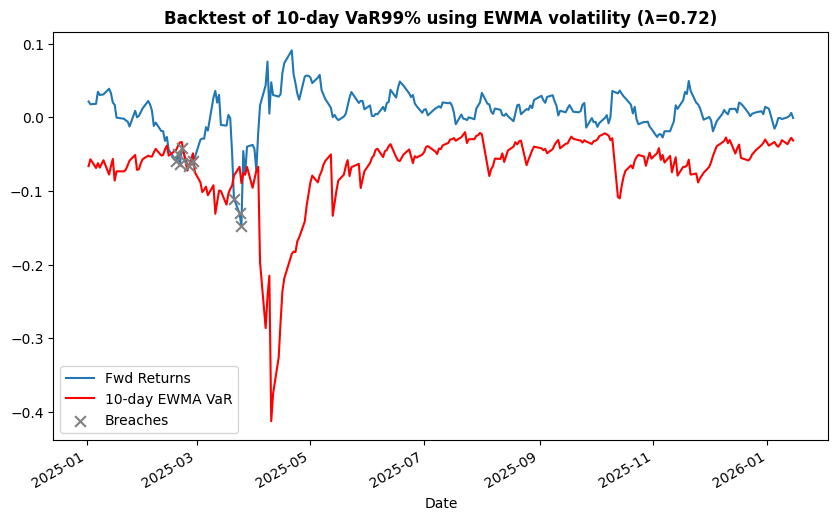

In [8]:
#EWMA 

lambda_ = 0.72

#loop over returns to calculate ewma of the next period

ewma_var = np.zeros(len(returns_3))

for t in range(1, len(returns_3)):
    ewma_var[t] = lambda_ * ewma_var[t-1] + (1 - lambda_) * returns_3.iloc[t-1]**2

ewma_vol = pd.Series(np.sqrt(ewma_var), index=returns_3.index)

#plot returns, rolling vol and ewma vol
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(returns_3.index, returns_3, label='Daily Returns', color='blue')
ax.plot(sd_10d.index, sd_10d, label='10-day Rolling Volatility', color='orange')
ax.plot(ewma_vol.index, ewma_vol, label='EWMA Volatility (Lbd=0.72)', color='green')
title = "daily returns, 10-day rolling volatility and EWMA volatility of SP500"
ax.set_title(title, fontweight='bold')
ax.legend(loc='upper left')

#scale ewma vol to 10d
sd_10d_ewma = np.sqrt(10) * ewma_vol

#calculate 10 day VaR series using EWMA vol
VaR_10d_ewma = norm.ppf(tail_prob) * sd_10d_ewma

#fresh figure for EWMA backtest
fig_ewma, ax_ewma = plt.subplots(figsize=(10, 6))
fwd_r_3.iloc[roll_window:].plot(ax=ax_ewma, label='Fwd Returns')
VaR_10d_ewma.iloc[roll_window:len(fwd_r_3.dropna())].plot(ax=ax_ewma, label='10-day EWMA VaR', color='red')

#calc breaches
breaches_ewma = fwd_r_3.iloc[roll_window:] < VaR_10d_ewma.iloc[roll_window:]

#add breaches
breaches_ewma_idx = breaches_ewma[breaches_ewma].index
ax_ewma.scatter(breaches_ewma_idx, fwd_r_3.loc[breaches_ewma_idx], color='grey', marker='x', s=60, label='Breaches', zorder=4)

#sanity check to ensure plot range is the same
print(f'Plotted range: {fwd_r_3.index[roll_window]:%Y-%m-%d} to {fwd_r_3.index[-(shift+1)]:%Y-%m-%d}')
print(f"Plotted var range: {VaR_10d_ewma.index[roll_window]:%Y-%m-%d} to {VaR_10d_ewma.index[len(fwd_r_3.dropna())-1]:%Y-%m-%d}")
print(f"backtest contains {len(breaches_ewma)} days")
print()

#reporting breaches
breach_count_ewma = np.sum(breaches_ewma)
observations_ewma = len(breaches_ewma)
breach_string_ewma = f'VaR breached {breach_count_ewma} times out of {observations_ewma} observations ({breach_count_ewma/observations_ewma:.2%})'

#add title and legend
ax_ewma.set_title(f"Backtest of 10-day VaR99% using EWMA volatility (λ=0.72)", fontweight='bold')
ax_ewma.legend(loc='lower left')


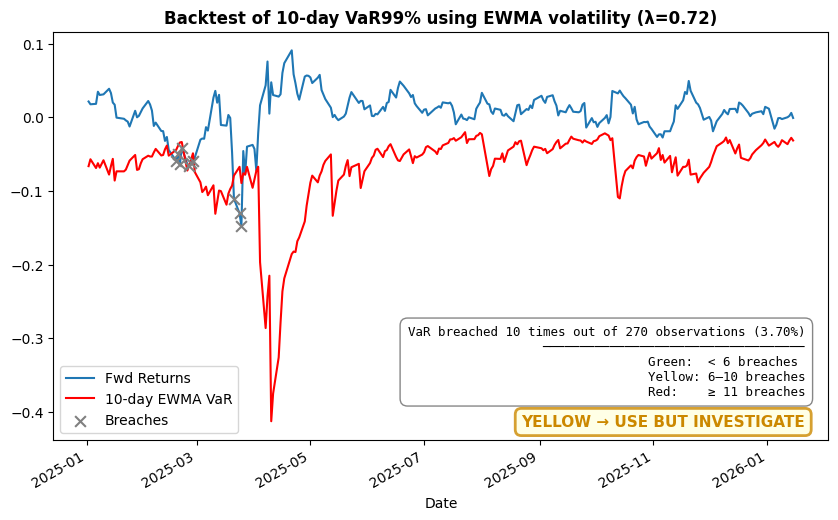

In [9]:
#Implementing RYG status for EWMA backtest

g_threshold_ewma = binom.ppf(g_prob, observations_ewma, tail_prob)
y_threshold_ewma = binom.ppf(y_prob, observations_ewma, tail_prob)

RYG_status_ewma = 'Green' if breach_count_ewma < g_threshold_ewma else 'Yellow' if breach_count_ewma < y_threshold_ewma else 'Red'

# Add comprehensive RYG info box to the plot
info_text_ewma = (
    f"{breach_string_ewma}\n"
    f"───────────────────────────────────\n"
    f"Green:  < {g_threshold_ewma:.0f} breaches \n"
    f"Yellow: {g_threshold_ewma:.0f}–{(y_threshold_ewma-1):.0f} breaches\n"
    f"Red:    ≥ {y_threshold_ewma:.0f} breaches"
)
box_props = dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='grey', alpha=0.95)
ax_ewma.text(0.97, 0.28, info_text_ewma, transform=ax_ewma.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right',
        bbox=box_props, family='monospace')

# Status line in bold coloured text
status_msg = {'Green': 'GREEN → ACCEPT', 'Yellow': 'YELLOW → USE BUT INVESTIGATE', 'Red': 'RED → DO NOT USE & INVESTIGATE'}
status_clr = {'Green': 'green', 'Yellow': '#CC8800', 'Red': 'red'}
ax_ewma.text(0.97, 0.062, status_msg[RYG_status_ewma], transform=ax_ewma.transAxes, fontsize=11,
        fontweight='bold', color=status_clr[RYG_status_ewma],
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                  edgecolor=status_clr[RYG_status_ewma], linewidth=2, alpha=0.80))

ax_ewma.get_figure().savefig('VaR_Backtest_EWMA2.png', dpi=300, bbox_inches='tight')
ax_ewma.get_figure()


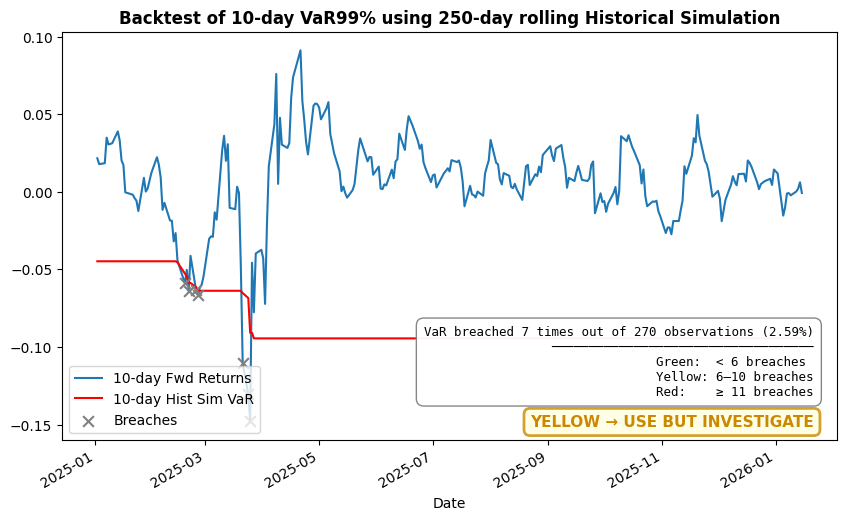

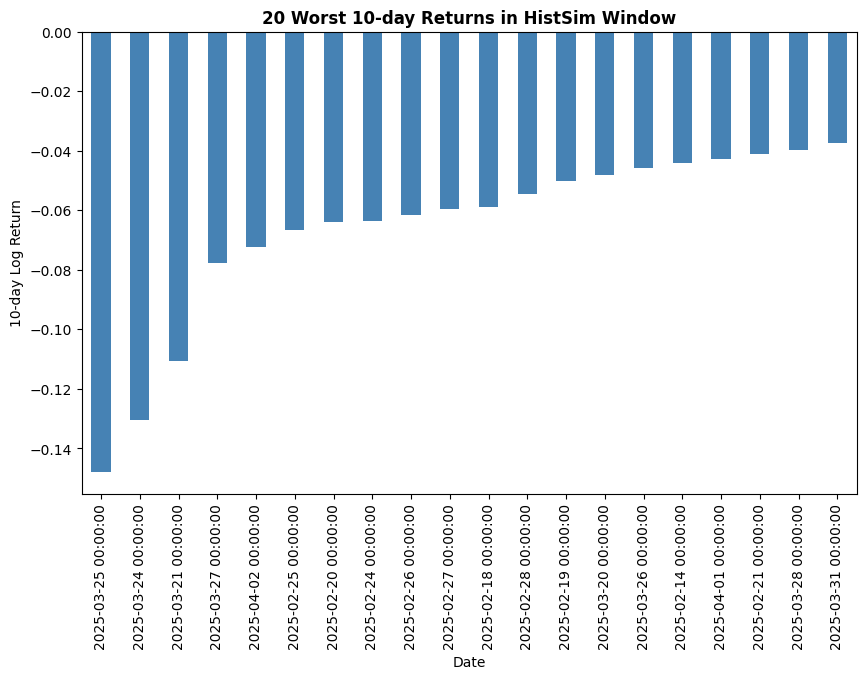

In [10]:

#HistSim VaR — use full return history so 250-day rolling window has enough data
returns_full = returns['^GSPC']
fwd_r_full = np.log(1 + returns_full).rolling(10).sum().shift(-10)  # keep trailing NaN to match 270-obs window

#calculate 99% hist sim VaR using a rolling window of 250 days
window_size = 250
hist_sim_var = fwd_r_full.rolling(window=window_size).quantile(tail_prob)

#slice to same backtest period as Task 3 — use fwd_r_3.index[-1] so trailing NaN days are included (270 obs)
bt_start = fwd_r_3.index[roll_window]
bt_end = fwd_r_3.index[-1]

#fresh figure for hist sim backtest
fig_hist, ax_hist = plt.subplots(figsize=(10, 6))
fwd_r_full.loc[bt_start:bt_end].plot(ax=ax_hist, label='10-day Fwd Returns')
hist_sim_var.loc[bt_start:bt_end].plot(ax=ax_hist, label='10-day Hist Sim VaR', color='red')

#calc breaches (NaN < NaN evaluates to False for the trailing 10 days — same as rolling VaR behaviour)
breaches_hist = fwd_r_full.loc[bt_start:bt_end] < hist_sim_var.loc[bt_start:bt_end]
breaches_hist_idx = breaches_hist[breaches_hist].index
ax_hist.scatter(breaches_hist_idx, fwd_r_full.loc[breaches_hist_idx], color='grey', marker='x', s=60, label='Breaches', zorder=4)

#reporting breaches
breach_count_hist = np.sum(breaches_hist)
observations_hist = len(breaches_hist)
breach_string_hist = f'VaR breached {breach_count_hist} times out of {observations_hist} observations ({breach_count_hist/observations_hist:.2%})'
ax_hist.set_title(f"Backtest of 10-day VaR99% using 250-day rolling Historical Simulation", fontweight='bold')
ax_hist.legend(loc='lower left')

#RYG status — reuse thresholds from Task 3 as observations are the same
RYG_status_hist = 'Green' if breach_count_hist < g_threshold else 'Yellow' if breach_count_hist < y_threshold else 'Red'
info_text_hist = (
    f"{breach_string_hist}\n"
    f"───────────────────────────────────\n"
    f"Green:  < {g_threshold:.0f} breaches \n"
    f"Yellow: {g_threshold:.0f}–{(y_threshold-1):.0f} breaches\n"
    f"Red:    ≥ {y_threshold:.0f} breaches"
)
box_props = dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='grey', alpha=0.95)
ax_hist.text(0.97, 0.28, info_text_hist, transform=ax_hist.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right',
        bbox=box_props, family='monospace')

status_msg = {'Green': 'GREEN → ACCEPT', 'Yellow': 'YELLOW → USE BUT INVESTIGATE', 'Red': 'RED → DO NOT USE & INVESTIGATE'}
status_clr = {'Green': 'green', 'Yellow': '#CC8800', 'Red': 'red'}
ax_hist.text(0.97, 0.062, status_msg[RYG_status_hist], transform=ax_hist.transAxes, fontsize=11,
        fontweight='bold', color=status_clr[RYG_status_hist],
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                  edgecolor=status_clr[RYG_status_hist], linewidth=2, alpha=0.80))
ax_hist.get_figure().savefig('VaR_Backtest_HistSim2.png', dpi=300, bbox_inches='tight')

#sanity check, order the worst 20,  10 day returns in the entire data set and print them together with their date

worst_20 = fwd_r_full.loc[bt_start:bt_end].nsmallest(20)

#plot the worst 20 returns as a bar chart — 2025 bars in blue, all others grey
bar_colors = ['steelblue' if d.year == 2025 else 'lightgrey' for d in worst_20.index]
fig_worst, ax_worst = plt.subplots(figsize=(10, 6))
worst_20.plot(kind='bar', ax=ax_worst, color=bar_colors)
ax_worst.set_title('20 Worst 10-day Returns in HistSim Window', fontweight='bold')
ax_worst.set_xlabel('Date')
ax_worst.set_ylabel('10-day Log Return')
ax_worst.get_figure().savefig('Worst_20_Returns2.png', dpi=300, bbox_inches='tight')


## Task 4 EWMA volatility forecasting

### Answer 4a

There are still 10 breaches, which equals 3.7\% of the observations, so the same as in 3a. 

### Answer 4b

The plot below shows the EWMA backtest. It is not a noticable improvement over the rolling sd backtest, with same RYG status. 

<img src="VaR_Backtest_EWMA2.png" width="100%">


### Answer 4c

To aid this question, I performed a HistSim backtest as well with a 250 day window (standard in industry). This backtest had 8 breaches, which is a significant improvement over the 10 breaches in the rolling sd and EWMA backtest. A further sophistication would be to select the 250 day window based on the period with the worst 10 day VaR.


<img src="VaR_Backtest_HistSim2.png" width="100%">

The approach with the best/worst adaptivity is dependent on how best is defined. If best is defined as lowest number of breaches, then the HistSim backtest is best. Once a 2025 market shocks became part of the 250 window, the VaR metric immediately adapted, allowing to avoid breaches in the following month. See for illustration the 3 worst returns, which are all due to "Liberation Day".


<img src="Worst_20_Returns2.png" width="100%">


If best is defined as quickest to react to a change in volatility, EWMA would be a better choice, as recent observations are weighted stronger than more distant ones, as such VaR will quickly adapt to a change in volatility. Note that the lambda parameter can be set to be more reactive by lowering it. In this assignment, the lambda parameter is lower than the standard 0.94 used in industry, hence it is more reactive than usual. The rolling window does not overweigh recent observations more, so in theory, for a 10 day rolling window a market shock will only be fully reflected in the VaR after 10 days, slower than EWMA. In this exercise, it does not seem to matter much.

***As a final conclusion, HistSim (especially when done based on ES and with a carefully selected window) is likely the best approach to minimize breaches. This is echo'd by the Basel 3 regulation as well.***